# wcc-phot: differential photometry of a WCC image series

Tutorial for **wcc_phot**, the photometry sibling of `wcc_sim`: it takes a series of
simulated WCC frames of the same field, picks a **target** plus the **N best reference
stars** (unsaturated, isolated, away from edges, closest in G to the target),
**re-centroids every star in every frame** from its WCS-predicted position, and builds a
differential (relative) light curve — with either **aperture** or **PSF-fit** fluxes.

**Requirements:** run with the `py313` conda env kernel. The Gaia queries are cached in
`gaia_cache/`, so after the first run this notebook works offline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import wcc_sim
import wcc_phot
from wcc_sim import simulate_field
from wcc_phot import run_photometry

plt.style.use('gks')
TEAL, RED, AMBER = '#00798c', '#d1495b', '#edae49'

print(f'wcc_sim {wcc_sim.__version__} | wcc_phot {wcc_phot.__version__}')

wcc_sim 0.1.0 | wcc_phot 0.1.0


## 1. Simulate a dithered series

Five 90 s exposures of the same Kepler-field pointing as notebook 01, on a 4096×4096
subarray (≈ 69″ × 69″), with sub-pixel pointing offsets between frames — the kind of
drift the per-frame centroiding is there to follow. `run_photometry` accepts the
`SimulatedField` objects directly (FITS paths work the same way).

In [2]:
RA0, DEC0 = 291.0, 44.5      # deg, ICRS (Kepler field)
EXPTIME = 90.0               # s
PIX_DEG = 16.87e-3 / 3600.0  # one IMX455 pixel in degrees

dithers_px = [(0.0, 0.0), (0.4, -0.2), (-0.3, 0.3), (0.1, 0.5), (-0.5, -0.1)]
frames = []
for k, (dx, dy) in enumerate(dithers_px):
    frames.append(simulate_field(
        ra=RA0 + dx * PIX_DEG, dec=DEC0 + dy * PIX_DEG,
        sensorfilter='zwo:r', focus=0, exptime=EXPTIME, seed=42 + k,
        shape=(4096, 4096), cache_dir='gaia_cache',
    ))
print(f"{len(frames)} frames, {frames[0].params['n_sources']} Gaia sources each")

5 frames, 32 Gaia sources each


## 2. Pick a target and run aperture photometry

The IMX455 effective full well is only ~16 ke⁻ and the in-focus PSF puts ~8% of the flux
in the peak pixel, so at 90 s any star brighter than G ≈ 18.2 saturates — we take the
unsaturated star closest to G = 18.5. `run_photometry` asks for the 10 best references;
in this sparse subfield only 7 survive the cuts, so it warns and continues. The default
aperture radius is the 95% encircled-energy radius of the wcc-sim PSF model for this
sensorfilter/focus/jitter, with the background annulus at 1.5–2.5 × r_ap.

In [3]:
cat = frames[0].catalog
ok = np.asarray(cat['in_image']) & ~np.asarray(cat['saturated'])
gmag = np.asarray(cat['phot_g_mean_mag'], dtype=float)
target_id = int(np.asarray(cat['source_id'])[ok][np.argmin(np.abs(gmag[ok] - 18.5))])

res_ap = run_photometry(frames, target=target_id, method='aperture', n_ref=10)
p = res_ap.params
print(f"target {p['target_source_id']}: r_ap={p['r_ap']} px "
      f"(model EE={p['ee_fraction']:.3f}), annulus {p['r_in']}-{p['r_out']} px, "
      f"{p['n_ref']} refs")
res_ap.stars

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-sim/src/wcc_phot/select.py:74: UserWarning: only 7 of 10 requested reference stars usable
  warnings.warn(


target 2126245824998773888: r_ap=9.0 px (model EE=0.950), annulus 13.5-22.5 px, 7 refs


star,role,source_id,ra,dec,gmag
int64,str6,int64,float64,float64,float64
0,target,2126245824998773888,290.9890463714144,44.49648012727523,18.62946128845215
1,ref,2126245790639056384,291.0028161167172,44.50461676375653,18.82853126525879
2,ref,2126245829297362176,290.98798994029636,44.50020075913573,19.419755935668945
3,ref,2126245756279295232,290.99211840952046,44.49629665426356,19.473852157592773
4,ref,2126245790639029504,291.0104300591018,44.49512296717736,19.576889038085938
5,ref,2126245794938018816,290.9966134142337,44.49911131045152,19.74286651611328
6,ref,2126245790639020032,291.0062397545951,44.49149253211353,20.31865119934082
7,ref,2126245898018198144,291.00928413138956,44.50399266810741,20.342300415039062


## 3. The field, with apertures

Target aperture + background annulus in red, reference apertures in teal, at the
re-centroided positions measured on the first frame.

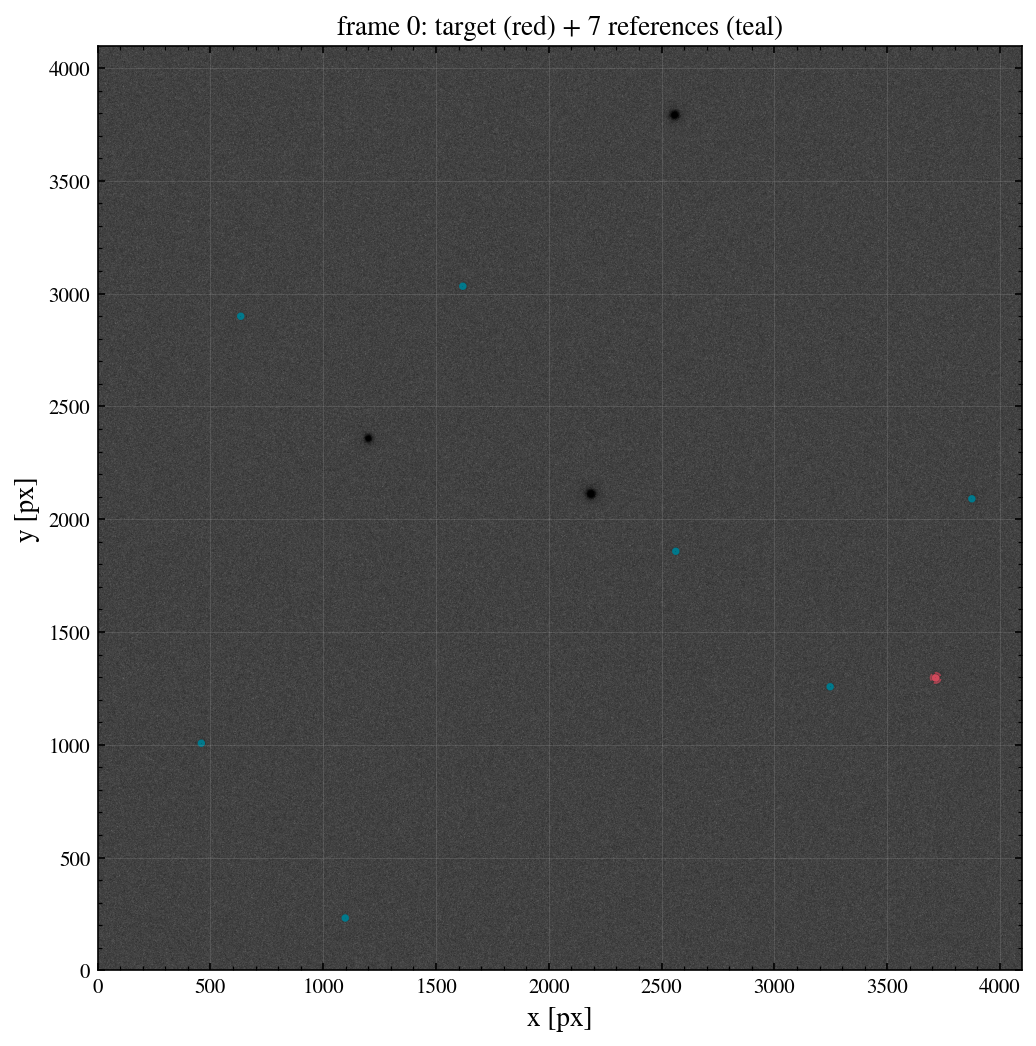

In [4]:
from astropy.visualization import simple_norm
from matplotlib.patches import Circle

frame0 = frames[0]
m0 = res_ap.measurements[res_ap.measurements['frame'] == 0]

fig, ax = plt.subplots(figsize=(8.5, 8))
norm = simple_norm(frame0.image_e, 'asinh', percent=99.7)
ax.imshow(frame0.image_e, origin='lower', cmap='gray_r', norm=norm)
for row in m0:
    color = RED if row['role'] == 'target' else TEAL
    ax.add_patch(Circle((row['x'], row['y']), p['r_ap'], fill=False, color=color, lw=1.6))
    if row['role'] == 'target':
        for r in (p['r_in'], p['r_out']):
            ax.add_patch(Circle((row['x'], row['y']), r, fill=False,
                                color=RED, lw=0.9, ls='--', alpha=0.7))
ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
ax.set_title(f"frame 0: target (red) + {p['n_ref']} references (teal)")
plt.show()

## 4. Relative light curve

The target flux is divided by the summed reference ensemble, normalized to its median.
For a constant star the scatter should be consistent with the propagated photon +
background + read-noise errors.

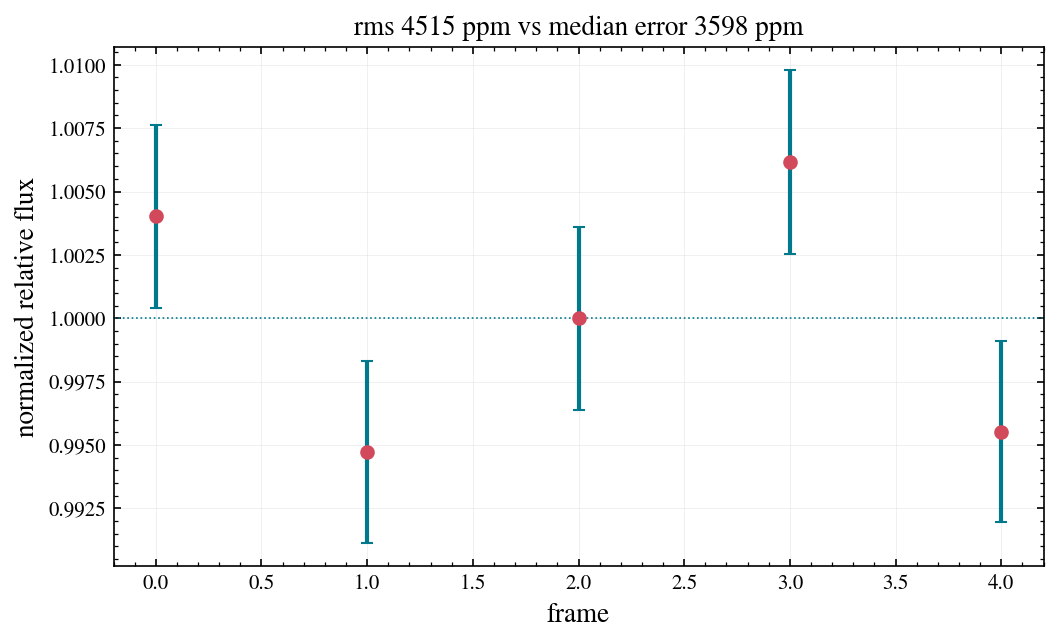

OK: rms 4515 ppm, consistent with 3598 ppm errors


In [5]:
lc = res_ap.lightcurve
rms = float(np.std(lc['rel_flux_norm']))
err = float(np.median(lc['rel_flux_norm_err']))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(lc['time'], lc['rel_flux_norm'], yerr=lc['rel_flux_norm_err'],
            fmt='o', color=RED, ecolor=TEAL, capsize=3)
ax.axhline(1.0, color=TEAL, lw=0.8, ls=':')
ax.set_xlabel('frame'); ax.set_ylabel('normalized relative flux')
ax.set_title(f'rms {1e6*rms:.0f} ppm vs median error {1e6*err:.0f} ppm')
plt.show()

assert rms < 4 * err, 'light-curve scatter should match the propagated errors'
print(f'OK: rms {1e6*rms:.0f} ppm, consistent with {1e6*err:.0f} ppm errors')

## 5. Per-frame centroiding

Each star starts at its WCS-predicted position (`x_init`, `y_init`) in every frame — so
the commanded dither is already taken out — and the center-of-mass refinement (`x`, `y`)
absorbs what's left. The predicted target position walks by up to half a pixel with the
dither pattern; the centroid residuals stay well under a tenth of a pixel.

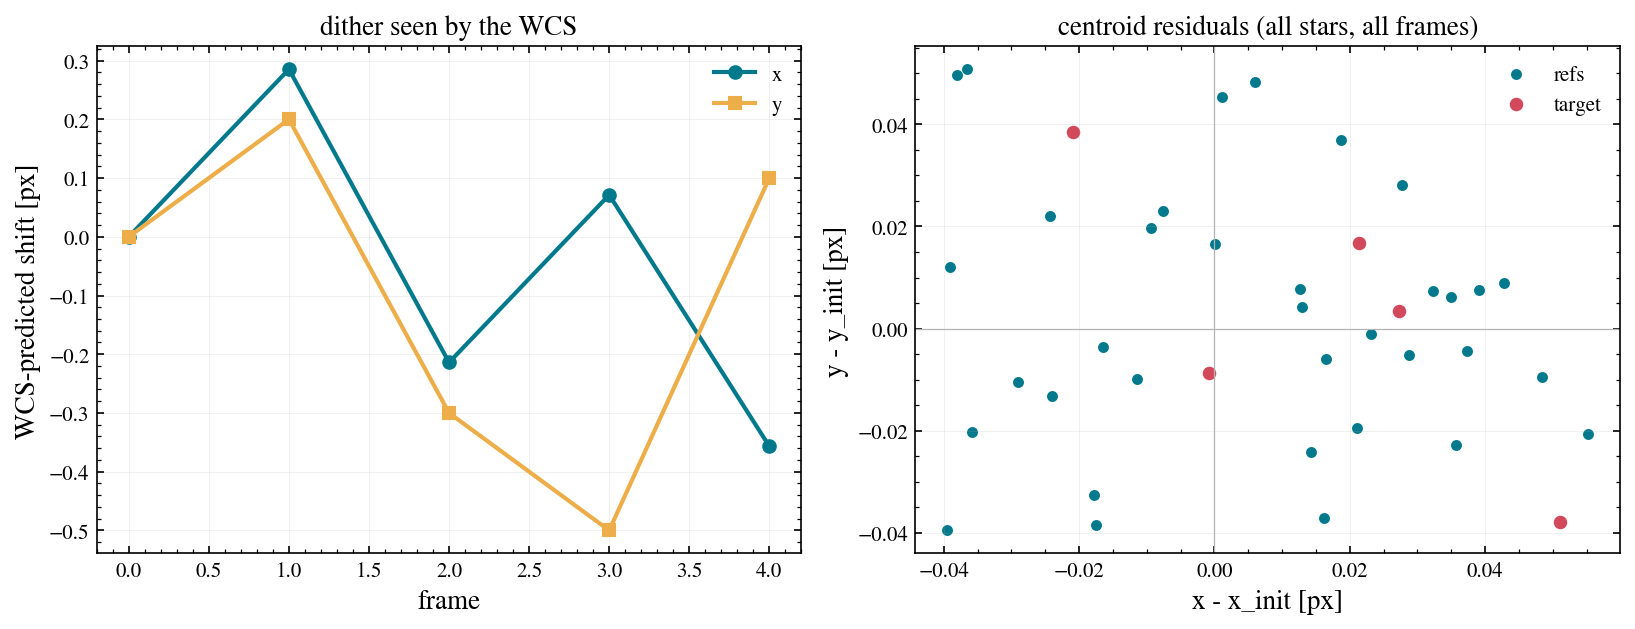

max centroid residual: 0.064 px


In [6]:
mm = res_ap.measurements
tgt = mm[mm['role'] == 'target']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(tgt['frame'], tgt['x_init'] - tgt['x_init'][0], 'o-', color=TEAL, label='x')
ax1.plot(tgt['frame'], tgt['y_init'] - tgt['y_init'][0], 's-', color=AMBER, label='y')
ax1.set_xlabel('frame'); ax1.set_ylabel('WCS-predicted shift [px]')
ax1.set_title('dither seen by the WCS'); ax1.legend()

is_target = mm['role'] == 'target'
ax2.scatter(mm['x'][~is_target] - mm['x_init'][~is_target],
            mm['y'][~is_target] - mm['y_init'][~is_target],
            s=18, color=TEAL, label='refs')
ax2.scatter(mm['x'][is_target] - mm['x_init'][is_target],
            mm['y'][is_target] - mm['y_init'][is_target],
            s=30, color=RED, label='target')
ax2.axhline(0, color='0.7', lw=0.6); ax2.axvline(0, color='0.7', lw=0.6)
ax2.set_xlabel('x - x_init [px]'); ax2.set_ylabel('y - y_init [px]')
ax2.set_title('centroid residuals (all stars, all frames)'); ax2.legend()
plt.tight_layout(); plt.show()

max_resid = float(np.max(np.hypot(mm['x'] - mm['x_init'], mm['y'] - mm['y_init'])))
assert max_resid < 0.5, 'centroids should stay near the WCS prediction'
print(f'max centroid residual: {max_resid:.3f} px')

## 6. PSF photometry

`method='psf'` fits every star with the same wcc-sim PSF model (rendered for this
sensorfilter/focus/jitter and wrapped as a photutils `ImagePSF`), initialized from the
centroid + aperture pass. PSF fluxes are *total* fluxes, so the aperture/PSF flux ratio
of the target should sit near the model encircled-energy fraction at r_ap; the relative
light curves should agree.

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-sim/src/wcc_phot/select.py:74: UserWarning: only 7 of 10 requested reference stars usable
  warnings.warn(


aperture/PSF target flux ratio: 0.956 (model EE at r_ap: 0.950)


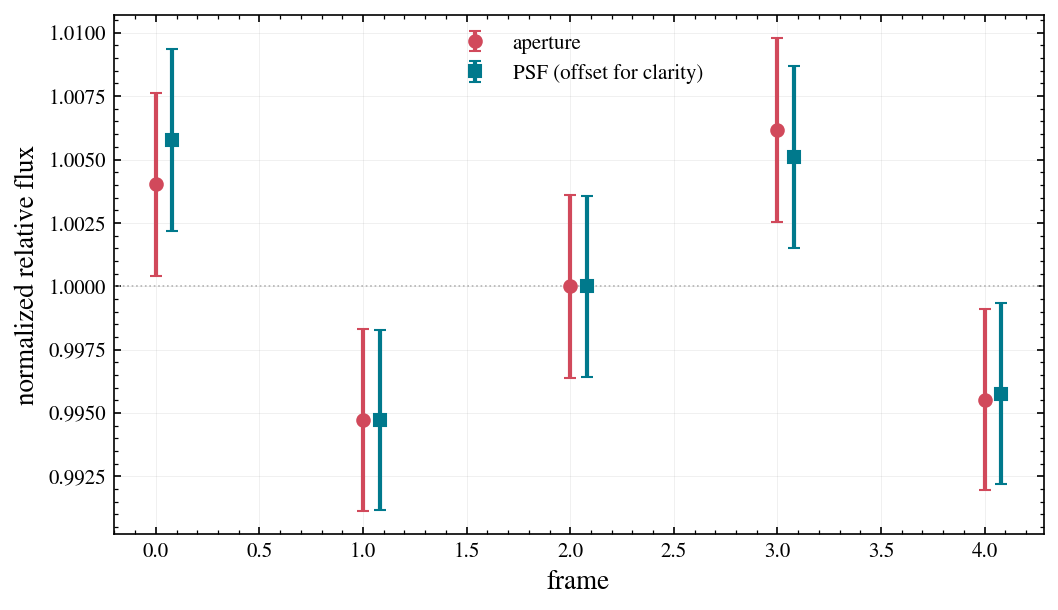

In [7]:
res_psf = run_photometry(frames, target=target_id, method='psf', n_ref=10)

flux_ratio = float(np.median(
    res_ap.measurements['flux_e'][res_ap.measurements['role'] == 'target']
    / res_psf.measurements['flux_e'][res_psf.measurements['role'] == 'target']
))
print(f"aperture/PSF target flux ratio: {flux_ratio:.3f} "
      f"(model EE at r_ap: {p['ee_fraction']:.3f})")
assert abs(flux_ratio - p['ee_fraction']) < 0.05

lc_psf = res_psf.lightcurve
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(lc['time'], lc['rel_flux_norm'], yerr=lc['rel_flux_norm_err'],
            fmt='o', color=RED, capsize=3, label='aperture')
ax.errorbar(np.asarray(lc_psf['time']) + 0.08, lc_psf['rel_flux_norm'],
            yerr=lc_psf['rel_flux_norm_err'], fmt='s', color=TEAL, capsize=3,
            label='PSF (offset for clarity)')
ax.axhline(1.0, color='0.7', lw=0.8, ls=':')
ax.set_xlabel('frame'); ax.set_ylabel('normalized relative flux'); ax.legend()
plt.show()

## 7. Watching it live

`run_photometry(..., on_frame=...)` calls any callable after each frame is measured with
an event dict (image, centroided positions, geometry, fluxes, running relative flux) —
that's the hook for custom displays. `wcc_phot.LiveViewer` is the built-in matplotlib
one: frame + apertures on the left, the growing light curve on the right, updated as
each image is analyzed. From the shell it's just:

```bash
wcc-phot series*.fits --source-id <id> --live -o phot.fits
```

(`--live-zoom 250` crops the image panel around the target, `--live-pause` sets the
update cadence). In a notebook the same viewer animates with an interactive backend
(`%matplotlib widget`); with the inline backend we can still run it and show the final
state:

In [8]:
events = []
_ = run_photometry(frames[:2], target=target_id, n_ref=10, on_frame=events.append)
print('event keys:', sorted(events[0].keys()))
print('streamed rel_flux:', [round(e['rel_flux'], 4) for e in events])

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-sim/src/wcc_phot/select.py:74: UserWarning: only 7 of 10 requested reference stars usable
  warnings.warn(


event keys: ['flags', 'flux_e', 'flux_err_e', 'frame', 'geom', 'image_e', 'n_frames', 'rel_flux', 'rel_flux_err', 'roles', 'time', 'wcs', 'x', 'y']
streamed rel_flux: [0.4295, 0.4256]


/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-sim/src/wcc_phot/select.py:74: UserWarning: only 7 of 10 requested reference stars usable
  warnings.warn(


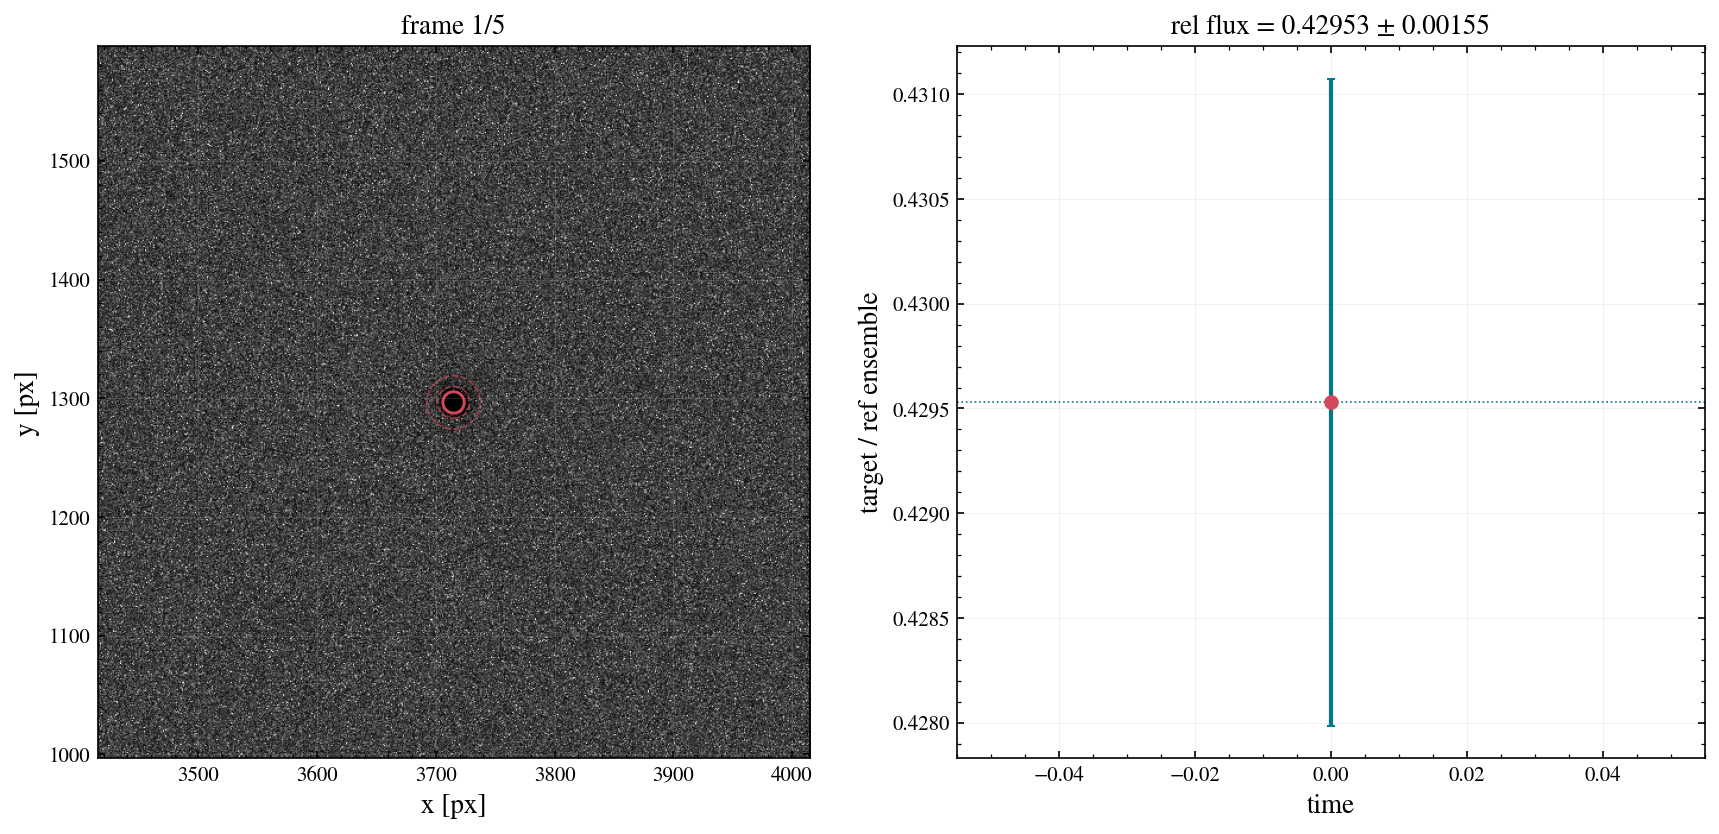

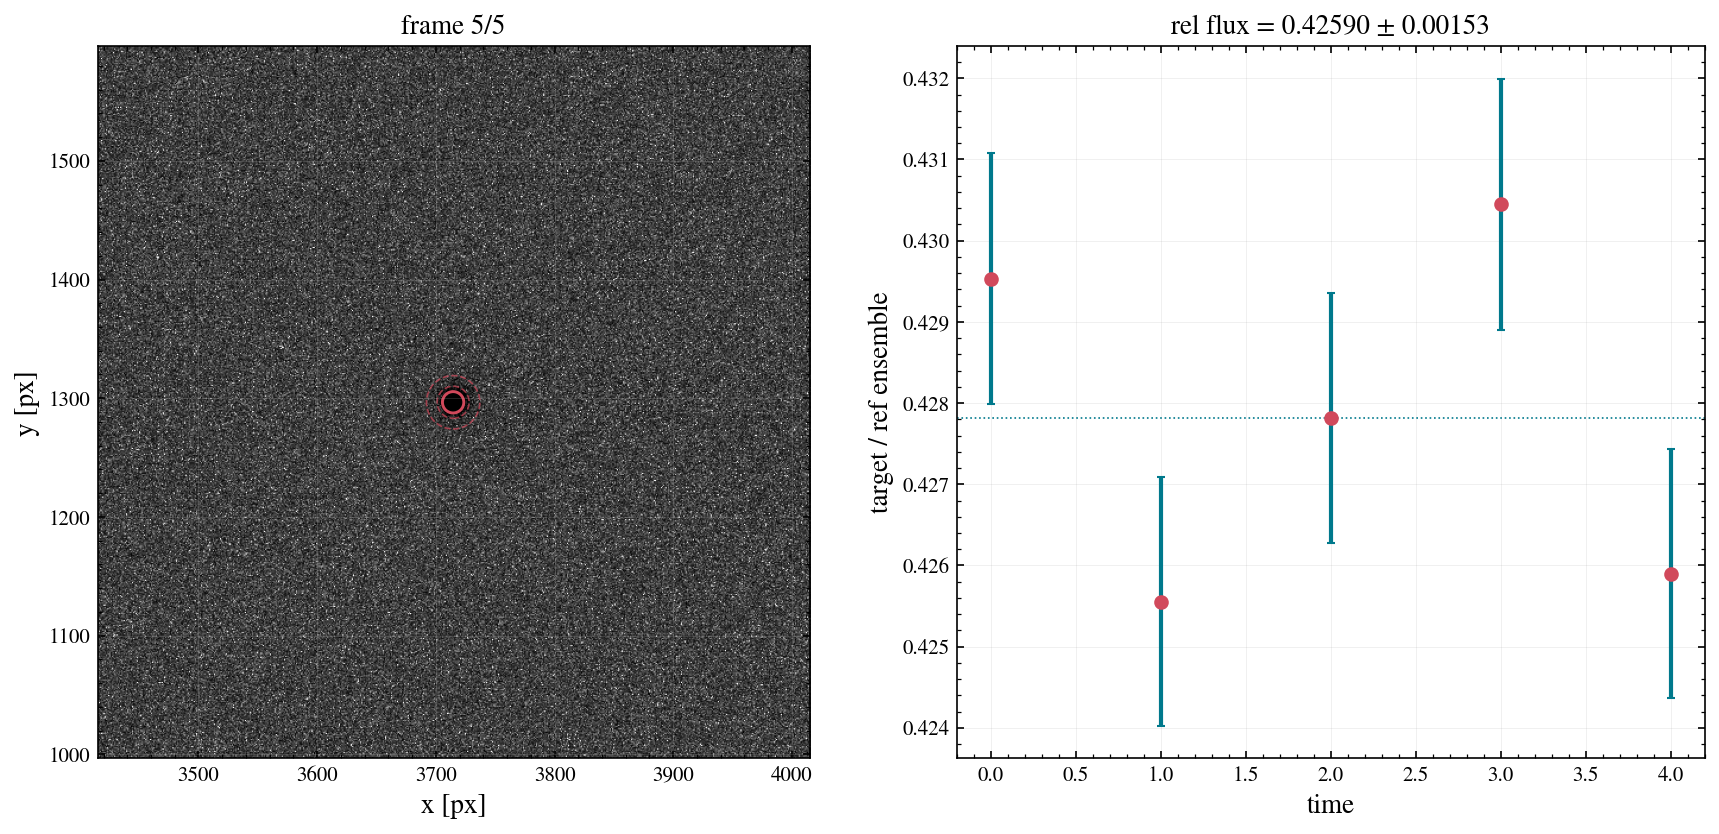

In [9]:
from wcc_phot import LiveViewer

viewer = LiveViewer(pause=0.01, zoom=300)
_ = run_photometry(frames, target=target_id, n_ref=10, on_frame=viewer)
viewer._fig

## Summary

- `run_photometry(frames, target, method='aperture'|'psf', n_ref=10)` → target + best-N
  reference selection, per-frame WCS-seeded COM centroiding, model-PSF-driven aperture
  geometry (or `ImagePSF` fitting), ensemble relative light curve.
- Results: `.stars` (selection), `.measurements` (per star per frame, with `flags` for
  centroid-fallback / saturation / edge), `.lightcurve`, `.params`; `.write()` saves a
  STARS/PHOT/LC FITS.
- CLI: `wcc-phot frames*.fits --source-id ... [--method psf] [--live] -o phot.fits`
  (see `scripts/example_photometry.sh`).
- Live displays hook in through `on_frame` — `LiveViewer` or anything you write.